<a href="https://colab.research.google.com/github/zombie9088/Pytorch_learning/blob/main/using_nn_module%2C_optimiser%2C_loss_func.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [48]:
df= pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [49]:
df.shape

(569, 33)

In [50]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [51]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0], test_size=0.2)

In [52]:
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


In [53]:
X_train

array([[-0.20281079, -0.52126108, -0.26513088, ..., -0.70374293,
        -0.23941342, -0.48523186],
       [-0.62111439,  0.51395856, -0.63364095, ..., -0.6641999 ,
        -0.75021119,  0.03147653],
       [ 0.83867979,  0.3941624 ,  0.81857695, ...,  1.01227242,
        -0.43833796, -0.47607227],
       ...,
       [ 0.30655209, -1.36661511,  0.23596047, ..., -0.52260544,
        -0.66760693, -0.92489197],
       [-0.7377841 , -0.1144062 , -0.764987  , ..., -0.80579436,
         0.71306428, -0.7794162 ],
       [-0.81461537, -1.01174725, -0.84568865, ..., -1.51285413,
        -0.11466412, -0.57359492]])

In [54]:
y_train

,diagnosis
364,B
115,B
335,M
124,B
210,M
...,...
315,B
480,B
371,B
55,B


In [55]:
encoder= LabelEncoder()
y_train= encoder.fit_transform(y_train)
y_test= encoder.transform(y_test)

In [56]:
y_train

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,

In [57]:
import torch

In [58]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()

In [59]:
X_train_tensor.shape

torch.Size([455, 30])

In [60]:
y_train_tensor.shape

torch.Size([455])

In [61]:
#define Model
import torch.nn as nn
class MySimpleNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.linear= nn.Linear(num_features,1)
    self.sigmoid= nn.Sigmoid()

  def forward(self,features):
    out= self.linear(features)
    out= self.sigmoid(out)
    return out




In [62]:
#parameters

learning_rate= 0.1
epochs=25

In [63]:
loss_function= nn.BCELoss()


In [64]:
#create model
model= MySimpleNN(X_train_tensor.shape[1])

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# List to store loss values
losses = []

#forward pass
for epoch in range(epochs):
  y_pred= model(X_train_tensor)



#loss calculate
  loss= loss_function(y_pred,y_train_tensor.view(-1,1))
  losses.append(loss.item())

#clear gradient
  optimizer.zero_grad()

#backward pass
  loss.backward()

#parameters update
  optimizer.step()



  print(f'Epoch :{epoch + 1}, Loss : {loss.item()}')


Epoch :1, Loss : 0.6074865460395813
Epoch :2, Loss : 0.4936096966266632
Epoch :3, Loss : 0.4258051812648773
Epoch :4, Loss : 0.38028380274772644
Epoch :5, Loss : 0.3471890985965729
Epoch :6, Loss : 0.3217756450176239
Epoch :7, Loss : 0.3014751076698303
Epoch :8, Loss : 0.2847718596458435
Epoch :9, Loss : 0.27071043848991394
Epoch :10, Loss : 0.25865674018859863
Epoch :11, Loss : 0.2481716424226761
Epoch :12, Loss : 0.23894064128398895
Epoch :13, Loss : 0.2307317852973938
Epoch :14, Loss : 0.22336965799331665
Epoch :15, Loss : 0.21671882271766663
Epoch :16, Loss : 0.2106727808713913
Epoch :17, Loss : 0.2051464319229126
Epoch :18, Loss : 0.20007075369358063
Epoch :19, Loss : 0.1953890472650528
Epoch :20, Loss : 0.1910543143749237
Epoch :21, Loss : 0.18702706694602966
Epoch :22, Loss : 0.18327389657497406
Epoch :23, Loss : 0.17976631224155426
Epoch :24, Loss : 0.17647983133792877
Epoch :25, Loss : 0.17339320480823517


In [65]:
model.linear.bias

Parameter containing:
tensor([-0.1852], requires_grad=True)

In [66]:
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.9).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.5831024646759033


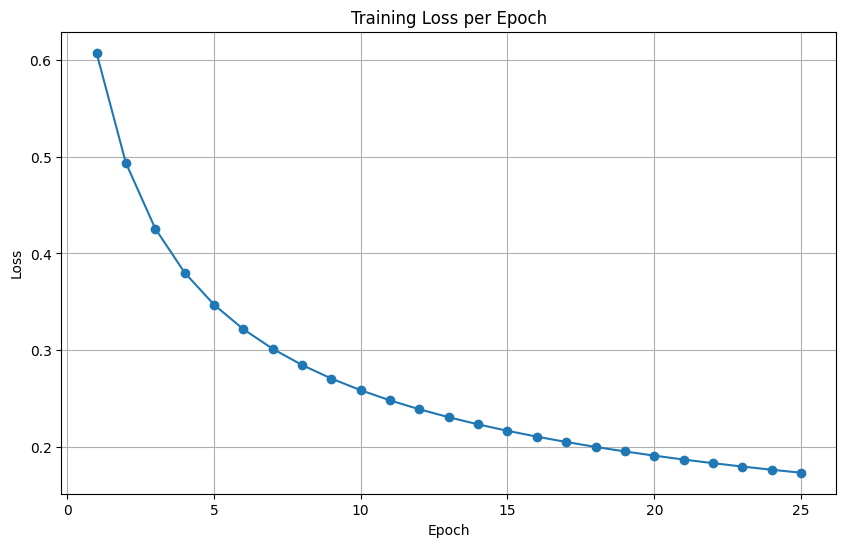

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()